In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.utils.validation import check_is_fitted, check_X_y, check_array
from sklearn.utils.estimator_checks import check_estimator
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import BaseEstimator, RegressorMixin

## 1. Data preparation & exploratory analysis

a) Load crime.csv. Display the first five rows, all column data types, and the dataset shape

In [134]:
# Load the data
df = pd.read_csv('../data/raw/crime.csv')

In [135]:
# Display the first five rows
print(df.head(5))
# Display all columns data types
print(df.dtypes)
# Display the dataset shape
print(df.shape)

        state  murder.rate  poverty  high.school  college  single.parent  \
0     Alabama          7.4     14.7         77.5     20.4           26.0   
1      Alaska          4.3      8.4         90.4     28.1           23.2   
2     Arizona          7.0     13.5         85.1     24.6           23.5   
3    Arkansas          6.3     15.8         81.7     18.4           24.7   
4  California          6.1     14.0         81.2     27.5           21.8   

   unemployed  metropolitan region  
0         4.6          70.2  South  
1         6.6          41.6   West  
2         3.9          87.9   West  
3         4.4          49.0  South  
4         4.9          96.7   West  
state                str
murder.rate      float64
poverty          float64
high.school      float64
college          float64
single.parent    float64
unemployed       float64
metropolitan     float64
region               str
dtype: object
(50, 9)


b) Report descriptive statistics (mean, std, min, max, quartiles) for all numeric variables.

In [136]:
# Report descriptive statistics
print(df.describe())

       murder.rate    poverty  high.school    college  single.parent  \
count    50.000000  50.000000    50.000000  50.000000      50.000000   
mean      4.604000  11.440000    85.482000  24.932000      22.970000   
std       2.510221   2.937096     3.959782   4.312319       3.038814   
min       0.600000   7.300000    77.100000  15.300000      13.600000   
25%       2.600000   9.425000    82.525000  22.525000      20.950000   
50%       4.550000  10.550000    86.100000  24.450000      22.800000   
75%       6.300000  13.375000    88.175000  27.450000      24.575000   
max      12.500000  19.300000    91.800000  34.600000      30.000000   

       unemployed  metropolitan  
count   50.000000     50.000000  
mean     3.904000     67.726000  
std      0.947383     20.562099  
min      2.200000     27.900000  
25%      3.225000     49.800000  
50%      3.900000     70.250000  
75%      4.400000     84.375000  
max      6.600000    100.000000  


C) Check for missing values. Report the count and percentage of missing entries per column and state how missing values will be handled during modelling.

In [137]:
print(f"The number of missing values: \n{df.isnull().sum()}")
print(f"\nThe percentage of missing values: \n{df.isnull().mean().astype(str) + ' %'}")
print("\nSince there are no missing values in this dataset, we do not need to handle them."
      "\nHowever, imputing values or dropping rows that contain missing values is usually done when they exist.")

The number of missing values: 
state            0
murder.rate      0
poverty          0
high.school      0
college          0
single.parent    0
unemployed       0
metropolitan     0
region           0
dtype: int64

The percentage of missing values: 
state            0.0 %
murder.rate      0.0 %
poverty          0.0 %
high.school      0.0 %
college          0.0 %
single.parent    0.0 %
unemployed       0.0 %
metropolitan     0.0 %
region           0.0 %
dtype: str

Since there are no missing values in this dataset, we do not need to handle them.
However, imputing values or dropping rows that contain missing values is usually done when they exist.


d) Produce a correlation heat map and a pair plot for the numeric predictors and the target (murder). Comment on at least two notable relationships visible in the plots.

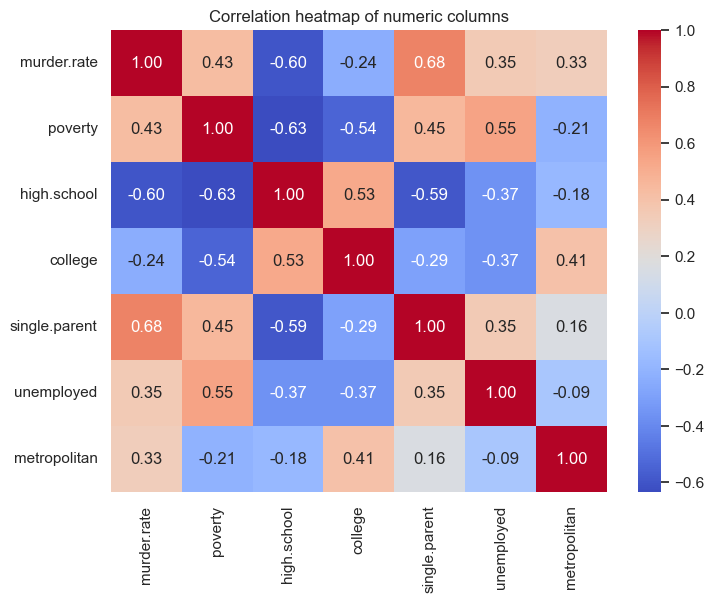

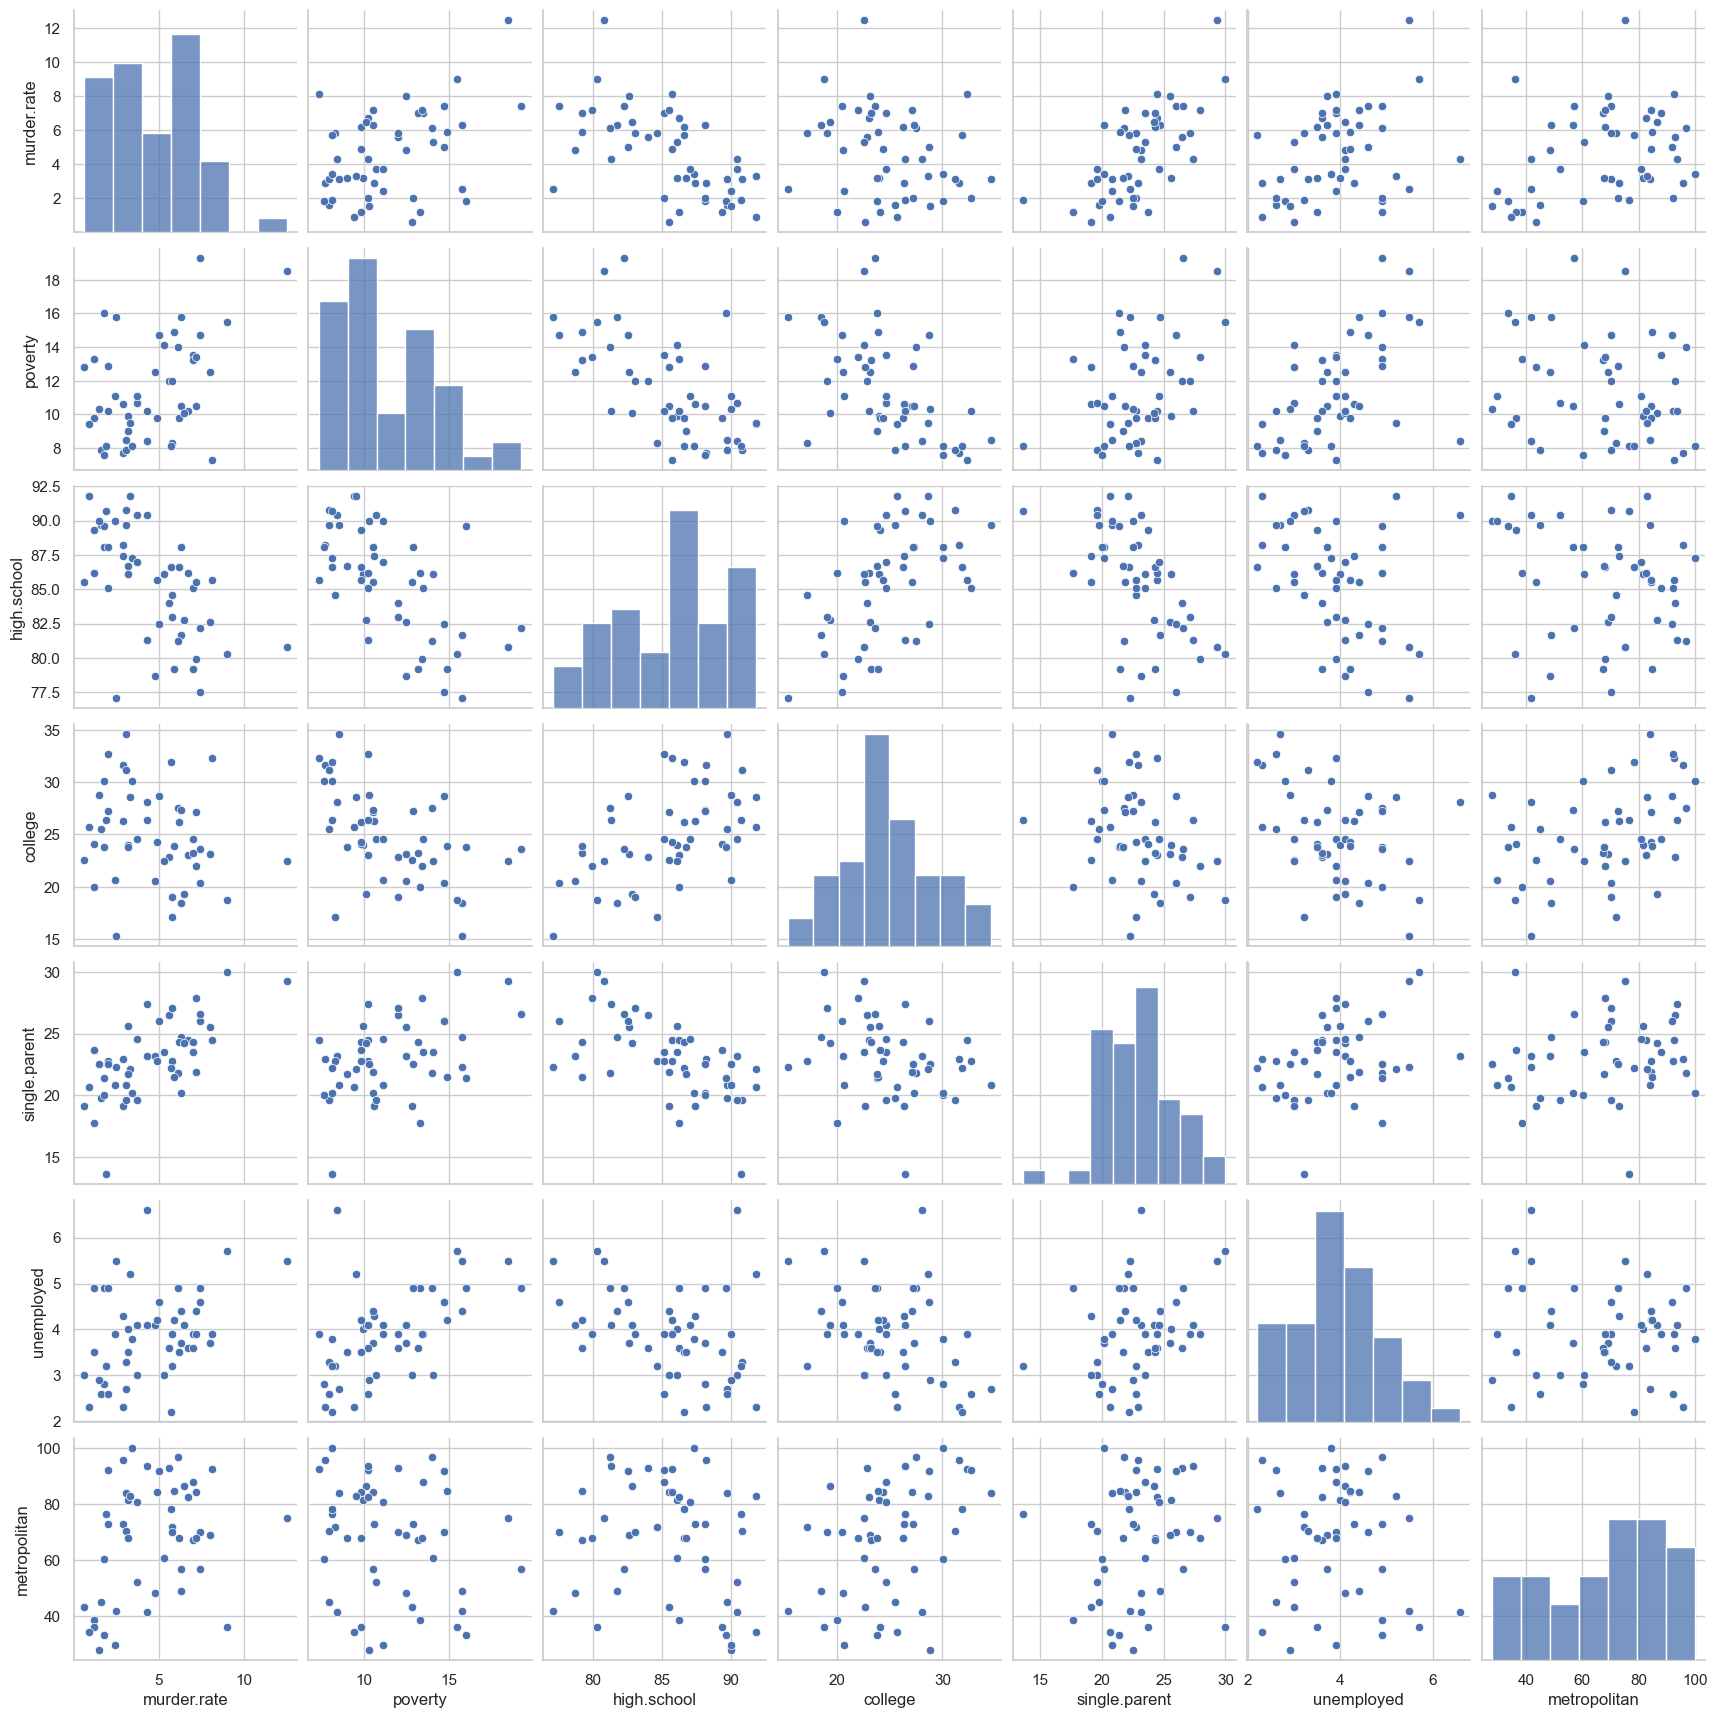

In [138]:
# Identify numericl columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Build correlation matrix and heatmap
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap of numeric columns")
plt.show()

# Pairwise scatterplot grid
sns.pairplot(df, vars=numeric_cols)
plt.show()

The analysis reveals a strong positive relationship between murder rates and the percentage of single-parent households. This may be due to reduced parental supervision or limited economic resources available to these families.Conversely, high school graduation rates are negatively correlated with murder rates. This suggests that attaining a high school education increases social and economic stability, whereas lower education levels are often associated with higher social instability and fewer opportunities.

e) Identify obvious outliers using box plots. State clearly how outliers will be handled (e.g., retained, capped, or removed) and justify your decision.

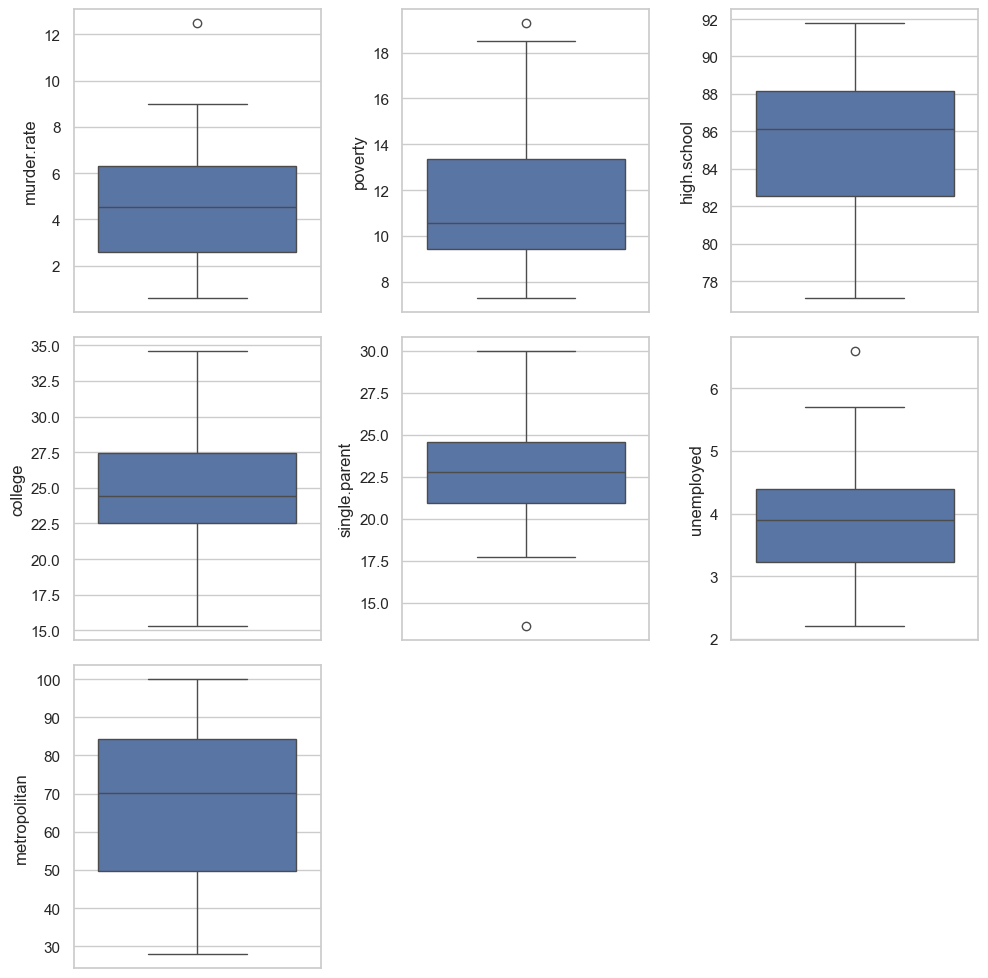

In [139]:
n_plots = len(numeric_cols)

# 3x3 grid
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols,
                         figsize=(10, 10), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_ylabel(col)

# hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Altough outlier exist in some column, they likely represent real high-crime regions rather than daata errors and this dataset has only 50 rows, each datapoint has much information compared to other dataset that has huge data points. So they were retained.

## 2. Scikit-learn baseline pipeline

a) Build a Pipeline that integrates a ColumnTransformer with the following steps in order
    Missing value imputation (median strategy for numeric features)
    One-hot-encoding for 'region' (with drop='first' to avoid multicollinearity)
    Standardization of all numeric features using StandardScaler
    scikit-learns' LinearRegression estimator

In [140]:
# Feature types
numerical_features = ['poverty', 'high.school', 'college', 'single.parent', 'unemployed', 'metropolitan']
categorical_features = ['region']

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute missing values
    ('scaler', StandardScaler()) # Scaling
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute missing values
    ('OneHot', OneHotEncoder(drop='first', sparse_output=False)) # Encoding
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr', LinearRegression()) # Normal linear regression
])

b) Split the data 50/50 (train/test) using random state=42 for reproducibility. Fit the pipeline on the training split and evaluate it on the test split. Report R2 and RMSE for both splits.

In [141]:
X = df.drop('murder.rate', axis=1).copy()
y = df['murder.rate']

In [142]:
# Split the data 50/50
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [143]:
# Fit pipeline
lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [144]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Scikit-learn baseline pipeline:")
print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")

print(f"RMSE train: {rmse_train:.4f}")
print(f"RMSE test: {rmse_test:.4f}")

Scikit-learn baseline pipeline:
R2 train: 0.7496
R2 test: 0.3021
RMSE train: 1.1517
RMSE test: 1.8506


c) Evaluate the pipeline using 3-fold cross-validation. Report the mean and standard deviation of R2 and RMSE across folds.

In [145]:
# CV for r2
r2_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=3,
    scoring='r2'
)

# CV for RMSE
rmse_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error'
)

# Make it positive
rmse_scores = -rmse_scores

r2_mean = r2_scores.mean()
r2_std = r2_scores.std()

rmse_mean = rmse_scores.mean()
rmse_std = rmse_scores.std()

print("3-fold cross-validation:")
print(f"R2 mean: {r2_mean:.4f}")
print(f"R2 std: {r2_std:.4f}")
print(f"RMSE mean: {rmse_mean:.4f}")
print(f"RMSE std: {rmse_std:.4f}")

3-fold cross-validation:
R2 mean: -0.7235
R2 std: 0.5672
RMSE mean: 2.6562
RMSE std: 0.2427


d) Compare the CV performance to the simple train/test result from (b). Discuss briefly: which estimate is more reliable and why?

The single train/test split produced positive R2 scores, which likely indicates overfitting to that specific subset of data.In contrast, cross-validation (CV) resulted in negative R2 scores, revealing that the model performs poorly when asked to generalizen. An R2 below zero suggests that the model is less accurate than a simple horizontal line representing the mean of the target variable. Furthermore, the CV-based RMSE is higher than the split-based RMSE.This confirms that while the model may appear to perform well on a single 'lucky' split, the cross-validation provides a more honest and pessimistic assessment of the model's true error magnitude on such a small dataset.

## 3. Mini-batch gradient descent from scratch

In [146]:
# Listing 1 from pdf instruction
class LinearRegressionGD_FullBatch(BaseEstimator, RegressorMixin):
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):   
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []
        self.n_features_in_ = X.shape[1]

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors ** 2).mean()   
            self.losses_.append(loss)
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

3.1. Implementation Requirements
Your modified class must satisfy all of the following:
    - Add a batch size parameter to init (default 8).
    - Use rgen.permutation to shuffle the training indices at the start of every epoch.
    - Slice the shuffled data into mini-batches without replacement. Retain the partial final batch if N is not divisible by batch size.
    - Apply the gradient update formulas exactly as stated in Algorithm 1 (sign convention must match Listing 1).
    - Append the epoch-level MSE (averaged over all batches in the epoch) to self.losses .
    - Ensure the class passes sklearn’s estimator checks (check estimator).

In [147]:
# Mini batch
class LinearRegressionGD_MiniBatch(BaseEstimator, RegressorMixin):
    def __init__(self, eta=0.01, n_iter=50, batch_size=8, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.batch_size = batch_size # Add batch size
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = 0. 
        self.losses_ = []
        self.n_features_in_ = X.shape[1]

        for i in range(self.n_iter):
            # Shuffle indices
            indices = rgen.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0.0
            n_batches = 0

            for start in range(0, X.shape[0], self.batch_size):
                # Slice the data
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                output = self.net_input(X_batch)
                errors = (y_batch - output) 
                
                self.w_ += self.eta * 2.0 * X_batch.T.dot(errors) / X_batch.shape[0]
                self.b_ += self.eta * 2.0 * errors.mean()
                
                batch_loss = (errors ** 2).mean()
                epoch_loss += batch_loss
                n_batches += 1

            # Append loss
            self.losses_.append(epoch_loss / n_batches)
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

In [148]:
# Ensure the class passes sklearn’s estimator checks
model = LinearRegressionGD_FullBatch()
try:
    check_estimator(model)
    print("All checks passed!")
except Exception as e:
    print(f"Check failed: {e}")

Check failed: Estimator should raise a NotFittedError when calling `predict` before fit. Either call `check_is_fitted(self)` at the beginning of `predict` or set `tags.requires_fit=False` on estimator tags to disable this check.
- `check_is_fitted`: https://scikit-learn.org/dev/modules/generated/sklearn.utils.validation.check_is_fitted.html
- Estimator Tags: https://scikit-learn.org/dev/developers/develop.html#estimator-tags


In [149]:
# Ensure the class passes sklearn’s estimator checks
model = LinearRegressionGD_MiniBatch()
try:
    check_estimator(model)
    print("All checks passed!")
except Exception as e:
    print(f"Check failed: {e}")

Check failed: Estimator should raise a NotFittedError when calling `predict` before fit. Either call `check_is_fitted(self)` at the beginning of `predict` or set `tags.requires_fit=False` on estimator tags to disable this check.
- `check_is_fitted`: https://scikit-learn.org/dev/modules/generated/sklearn.utils.validation.check_is_fitted.html
- Estimator Tags: https://scikit-learn.org/dev/developers/develop.html#estimator-tags


3.2 Training & Evaluation

a) Train the full-batch LinearRegressionGD (Listing 1) with n iter=500 and eta=0.01. Report training and test R2 and RMSE

In [150]:
full_batch = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr_full', LinearRegressionGD_FullBatch(eta=0.01, n_iter=500))
])

full_batch.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr_full', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [151]:
# Report R2 and RMSE
y_train_pred = full_batch.predict(X_train)
y_test_pred = full_batch.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Full batch model:")
print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")

print(f"RMSE train: {rmse_train:.4f}")
print(f"RMSE test: {rmse_test:.4f}")

Full batch model:
R2 train: 0.7337
R2 test: 0.1796
RMSE train: 1.1877
RMSE test: 2.0065


b) Train your mini-batch LinearRegressionGD with batch size=8, n iter=500, and eta=0.01. Report training and test R2 and RMSE.

In [152]:
mini_batch = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr_mini', LinearRegressionGD_MiniBatch(eta=0.01, n_iter=500, batch_size=8))
])
mini_batch.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr_mini', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [153]:
# Report R2 and RMSE
y_train_pred = mini_batch.predict(X_train)
y_test_pred = mini_batch.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Mini batch model:")
print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")

print(f"RMSE train: {rmse_train:.4f}")
print(f"RMSE test: {rmse_test:.4f}")


Mini batch model:
R2 train: 0.7465
R2 test: 0.2506
RMSE train: 1.1588
RMSE test: 1.9177


c) Plot the loss curve (epoch on the x-axis, MSE on the y-axis) for both models on the same axes. Confirm that the loss decreases and stabilises for each. Label each curve clearly.

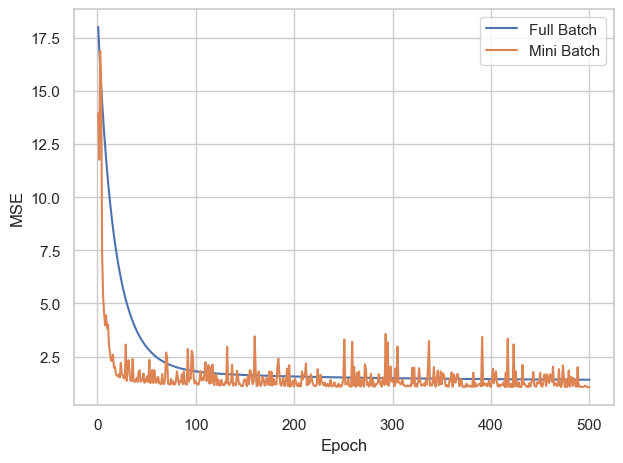

In [154]:
lr_full = full_batch.named_steps['lr_full'] 
lr_mini = mini_batch.named_steps['lr_mini']  

# Plot loss history
plt.plot(range(1, lr_full.n_iter+1), lr_full.losses_, label='Full Batch')
plt.plot(range(1, lr_mini.n_iter+1), lr_mini.losses_, label='Mini Batch')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
#plt.savefig('figures/09_06.png', dpi=300)
plt.show()

d) Compare the test-set R2 and RMSE of the two gradient-descent models to each other and to the scikit-learn baseline from Section 2. Discuss any differences.

Scikit-learn baseline (linear Regression with default hyperparameter):\n
R2 train: 0.7496\n
R2 test: 0.3021\n
RMSE train: 1.1517\n
RMSE test: 1.8506\n

Full batch:\n
R2 train: 0.7337\n
R2 test: 0.1796\n
RMSE train: 1.1877\n
RMSE test: 2.0065\n

Mini batch:\n
R2 train: 0.7465\n
R2 test: 0.2506\n
RMSE train: 1.1588\n
RMSE test: 1.917\n

Normal linear regression achieved R2 of 0.3, while full batch only hit 0.18. That means linear regression is able to capture more variance in the unseen data than full batch model. This suggest scikit-learn's default solver is more efficient at finding the optimal weights on a small dataset than full batch model.

Looking at the difference between mini and full batch, mini batch model performs better than full batch on test data. Mini batch is good at fiding a patter of unseen data because mini batch add the noise by randomizing the indices in the process.

As for the scikit-learn baseline and mini batch, same thing as the difference between full batch and normal linear regression can be applied. 

Normal linear regression performed best among those 3 models that I made. Additionally, In general, all models seems like they are overfitting because train models perform well, whereas test models don't perform well based on both R2 and RMSE scores. Those are expected due to the data size. This dataset has only 50 rows, that makes it training model overfitted. Adding more data such as county in each states or regularize the data would be a good idea to avoid overfitting.

## 4. Hyperparameter optimization -- learning rate & batch size

4.1  Grid Search over η and batch size

a) Report the mean CV score (R2 and RMSE) for every (η, batch size) combination in a summary table (rows = η, columns = batch size). Identify the optimal combination.

In [155]:
# Make a pipeline with mini batch
grid_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr_mini', LinearRegressionGD_MiniBatch(n_iter=500, random_state=1))
])

# Hyperparameter
param_grid = {
    'lr_mini__eta': [10e-4, 5*10e-4, 10e-3, 5*10e-3, 0.01, 0.05, 0.1],
    'lr_mini__batch_size': [8, 16, 32]
}

# Grid search with R2
gs_r2 = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    refit=True
)
gs_r2.fit(X_train, y_train)

# Grid search with RMSE
gs_rmse = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    refit=True 
)
gs_rmse.fit(X_train, y_train)

# Make dataframes
df_r2_results = pd.DataFrame(gs_r2.cv_results_)
r2_summary_table = df_r2_results.pivot_table(
    index='param_lr_mini__eta', 
    columns='param_lr_mini__batch_size', 
    values='mean_test_score'
)
df_rmse_results = pd.DataFrame(gs_rmse.cv_results_)
rmse_summary_table = df_rmse_results.pivot_table(
    index='param_lr_mini__eta', 
    columns='param_lr_mini__batch_size', 
    values='mean_test_score'
).abs()


print("=== [Result 1] R2 Summary Table (Rows: η, Cols: Batch Size) ===")
display(r2_summary_table)
print(f"R2 best parameters: {gs_r2.best_params_} (Score: {gs_r2.best_score_:.4f})")

print("\n" + "-"*50 + "\n")

print("=== [Result 2] RMSE Summary Table (Rows: η, Cols: Batch Size) ===")
display(rmse_summary_table)
print(f"RMSE best parameters: {gs_rmse.best_params_} (Score: {abs(gs_rmse.best_score_):.4f})")

=== [Result 1] R2 Summary Table (Rows: η, Cols: Batch Size) ===


param_lr_mini__batch_size,8,16,32
param_lr_mini__eta,,,
0.001,-0.097438,0.065979,0.230034
0.005,-0.383532,-0.390757,-0.238769
0.010,-0.448045,-0.414344,-0.328934
0.050,-0.757567,-0.700977,-0.531827
0.100,-0.861551,-0.885850,-0.634971


R2 best parameters: {'lr_mini__batch_size': 32, 'lr_mini__eta': 0.001} (Score: 0.2300)

--------------------------------------------------

=== [Result 2] RMSE Summary Table (Rows: η, Cols: Batch Size) ===


param_lr_mini__batch_size,8,16,32
param_lr_mini__eta,,,
0.001,2.051944,1.980641,1.904459
0.005,2.265409,2.254849,2.134254
0.010,2.355233,2.305912,2.202927
0.050,2.630263,2.562179,2.455220
0.100,2.681212,2.634367,2.566354


RMSE best parameters: {'lr_mini__batch_size': 32, 'lr_mini__eta': 0.001} (Score: 1.9045)


b) Visualize the performance as function of the hyperparameters.

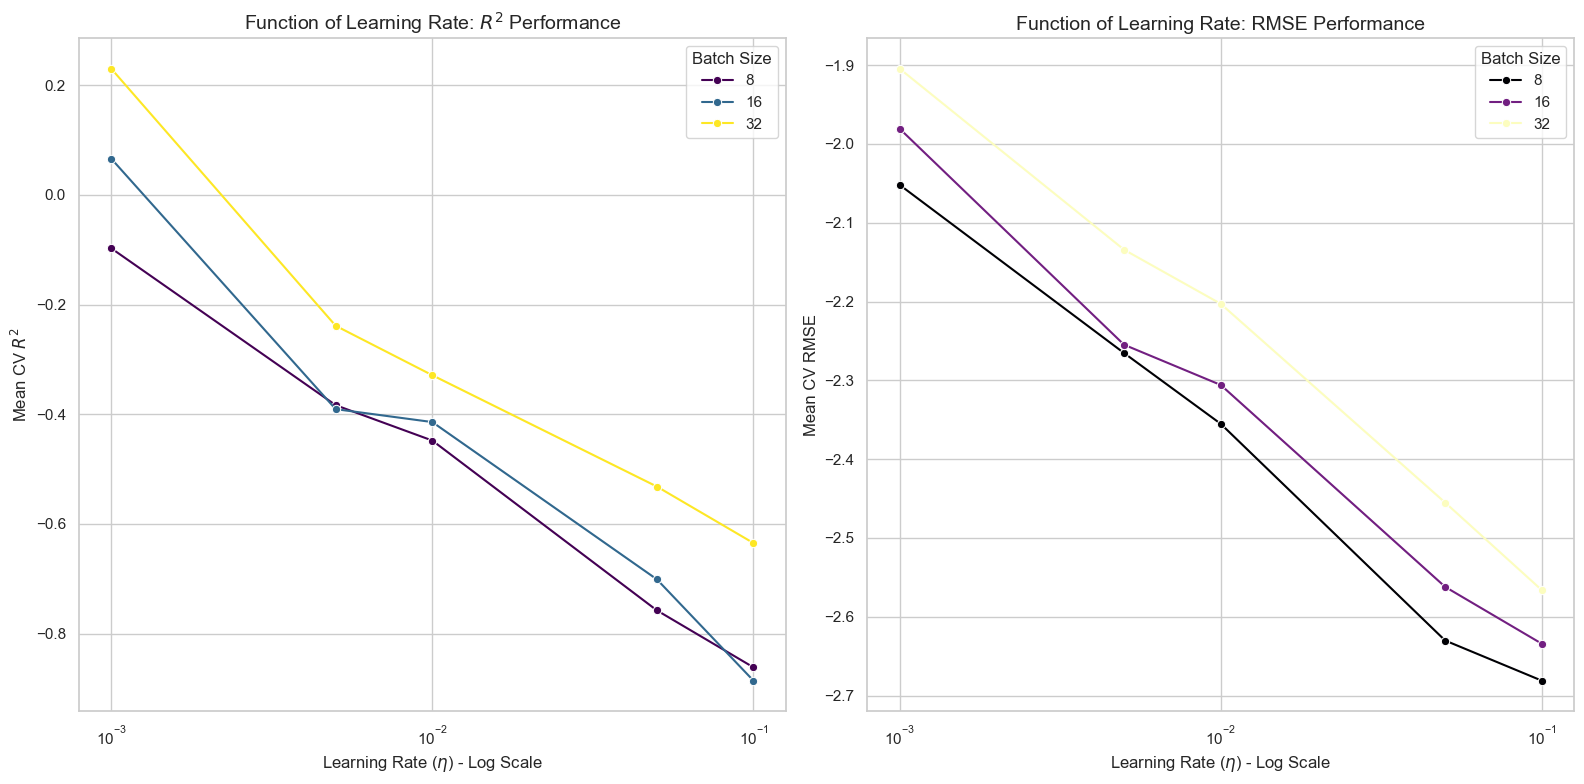

In [156]:
# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# --- Plot 1: R2 as a function of Eta ---
sns.lineplot(
    data=df_r2_results, 
    x='param_lr_mini__eta', 
    y='mean_test_score', 
    hue='param_lr_mini__batch_size', 
    marker='o', 
    ax=ax[0],
    palette='viridis'
)
ax[0].set_xscale('log') # Use log scale to see the spread of eta
ax[0].set_title('Function of Learning Rate: $R^2$ Performance', fontsize=14)
ax[0].set_xlabel(r'Learning Rate ($\eta$) - Log Scale', fontsize=12)
ax[0].set_ylabel('Mean CV $R^2$', fontsize=12)
ax[0].legend(title='Batch Size')

# --- Plot 2: RMSE as a function of Eta ---
sns.lineplot(
    data=df_rmse_results, 
    x='param_lr_mini__eta', 
    y='mean_test_score', 
    hue='param_lr_mini__batch_size', 
    marker='o', 
    ax=ax[1],
    palette='magma'
)
ax[1].set_xscale('log') # Use log scale
ax[1].set_title('Function of Learning Rate: RMSE Performance', fontsize=14)
ax[1].set_xlabel(r'Learning Rate ($\eta$) - Log Scale', fontsize=12)
ax[1].set_ylabel('Mean CV RMSE', fontsize=12)
ax[1].legend(title='Batch Size')

plt.tight_layout()
plt.show()

c) Refit your mini-batch LinearRegressionGD using the optimal (η, batch size) combination found in (a) on the full training set. Report final training and test R2 and RMSE. Produce an actual vs. predicted scatter plot on the test set with a reference diagonal.

In [157]:
# Refit with optimal hyperparameters
grid_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr_mini', LinearRegressionGD_MiniBatch(n_iter=500, eta=0.001, batch_size=32, random_state=1))
])

In [158]:
grid_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr_mini', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [159]:
y_train_pred = grid_pipeline.predict(X_train)
y_test_pred = grid_pipeline.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Mini batch model with optimal hyperparameters:")
print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")

print(f"RMSE train: {rmse_train:.4f}")
print(f"RMSE test: {rmse_test:.4f}")

Mini batch model with optimal hyperparameters:
R2 train: 0.4471
R2 test: -0.7072
RMSE train: 1.7113
RMSE test: 2.8944


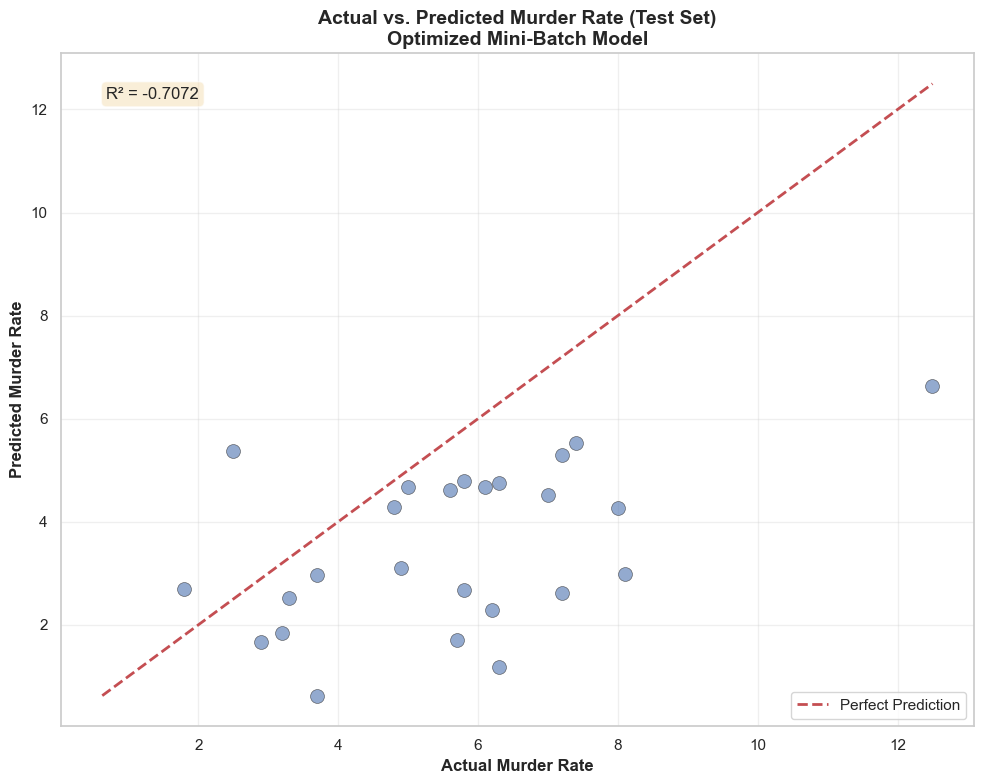

In [160]:
# Actual vs. Predicted scatter plot with reference diagonal
plt.figure(figsize=(10, 8))

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_test_pred, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)

# Reference diagonal (perfect predictions)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Murder Rate', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Murder Rate', fontsize=12, fontweight='bold')
plt.title('Actual vs. Predicted Murder Rate (Test Set)\nOptimized Mini-Batch Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add R2 annotation
plt.text(0.05, 0.95, f'R² = {r2_test:.4f}', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 5. Model comparison summary

## Discussion & Reflection
Address all four questions in complete sentences:
a) What do you believe you did well on this assignment?
    We believe we successfully organized the project documentation and effectively implemented baseline models beyond the Stochastic Gradient Descent (SGD) model, ensuring a comprehensive comparison.
b) What was the most challenging part of this assignment?
    The most challenging part was correctly defining the Mini-Batch Gradient Descent class, particularly in managing the data slicing and ensuring the logic adhered to scikit-learn's internal standards.
c) What would have made this assignment a better learning experience?
    Implementing a linear regression model with gradient descent from scratch was a valuable experience that significantly deepened our understanding of optimization algorithms.
d) What do you need help with going forward?
    We need more guidance on how to make custom estimators compatible with scikit-learn's check_estimator. While we think that we successfully adapted the full-batch version to a mini-batch version, we struggled to pass the official estimator checks. We found that even the provided baseline code did not pass these checks, which made us curious about that.